# 🎬 Movies Dataset – Exploratory Data Analysis (EDA)
**Module 3: Introduction to AI – Data Science**  
MSc. Stephanie Rodriguez Osorio

---
This notebook performs a complete EDA on the `movies.csv` dataset, including data cleaning, feature engineering, and visualizations.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully ✅')

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully ✅


## 2. Load the Dataset

In [2]:
df = pd.read_csv('movies.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded: 9742 rows × 3 columns


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


## 3. Basic Information

In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Basic Statistics ---')
df.describe(include='all')

--- Data Types ---
movieId     int64
title      object
genres     object
dtype: object

--- Missing Values ---
movieId    0
title      0
genres     0
dtype: int64

--- Basic Statistics ---


,movieId,title,genres
count,9742.000000,9742,9742
unique,NaN,9737,951
top,NaN,Emma (1996),Drama
freq,NaN,2,1053
mean,42200.353623,NaN,NaN
std,52160.494854,NaN,NaN
min,1.000000,NaN,NaN
25%,3248.250000,NaN,NaN
50%,7300.000000,NaN,NaN
75%,76232.000000,NaN,NaN


In [4]:
print('Sample unique titles:')
print(df['title'].sample(5, random_state=42).values)

Sample unique titles:
['Notorious Bettie Page, The (2005)'
 'Star Trek V: The Final Frontier (1989)' 'Starsky & Hutch (2004)'
 'Colonel Chabert, Le (1994)' 'Country Girl, The (1954)']


## 4. Data Cleaning – Extract Title and Year

The `title` column contains the movie name and release year in the format `"Movie Name (YYYY)"`.  
We will split this into two separate columns: **Title** and **Year**.

In [5]:
# Extract title and year using regex
extracted = df['title'].str.extract(r'^(.*?)\s*\((\d{4})\)\s*$')
df['Title'] = extracted[0].fillna(df['title'])  # fallback to original if no year found
df['Year']  = extracted[1]

# Convert Year to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

print(f'Rows with missing Year: {df["Year"].isnull().sum()}')
df[['movieId', 'title', 'Title', 'Year', 'genres']].head(10)

Rows with missing Year: 13


,movieId,title,Title,Year,genres
0,1,Toy Story (1995),Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale (1995),Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Father of the Bride Part II,1995.0,Comedy
5,6,Heat (1995),Heat,1995.0,Action|Crime|Thriller
6,7,Sabrina (1995),Sabrina,1995.0,Comedy|Romance
7,8,Tom and Huck (1995),Tom and Huck,1995.0,Adventure|Children
8,9,Sudden Death (1995),Sudden Death,1995.0,Action
9,10,GoldenEye (1995),GoldenEye,1995.0,Action|Adventure|Thriller


In [6]:
# Show rows where year could not be extracted
df[df['Year'].isnull()][['title', 'genres']]

,title,genres
6059,Babylon 5,Sci-Fi
9031,Ready Player One,Action|Sci-Fi|Thriller
9091,Hyena Road,(no genres listed)
9138,The Adventures of Sherlock Holmes and Doctor W...,(no genres listed)
9179,Nocturnal Animals,Drama|Thriller
9259,Paterson,(no genres listed)
9367,Moonlight,Drama
9448,The OA,(no genres listed)
9514,Cosmos,(no genres listed)
9515,Maria Bamford: Old Baby,(no genres listed)


## 5. Genre Analysis

The `genres` column uses `|` as a separator for multiple genres. We will explode this into individual rows for analysis.

In [7]:
# Explode genres into individual rows
genres_df = df.copy()
genres_df['genre'] = genres_df['genres'].str.split('|')
genres_df = genres_df.explode('genre')

# Remove movies with no genre listed
genres_df = genres_df[genres_df['genre'] != '(no genres listed)']

genre_counts = genres_df['genre'].value_counts()
print('Total unique genres:', len(genre_counts))
genre_counts

Total unique genres: 19


genre
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87
Name: count, dtype: int64

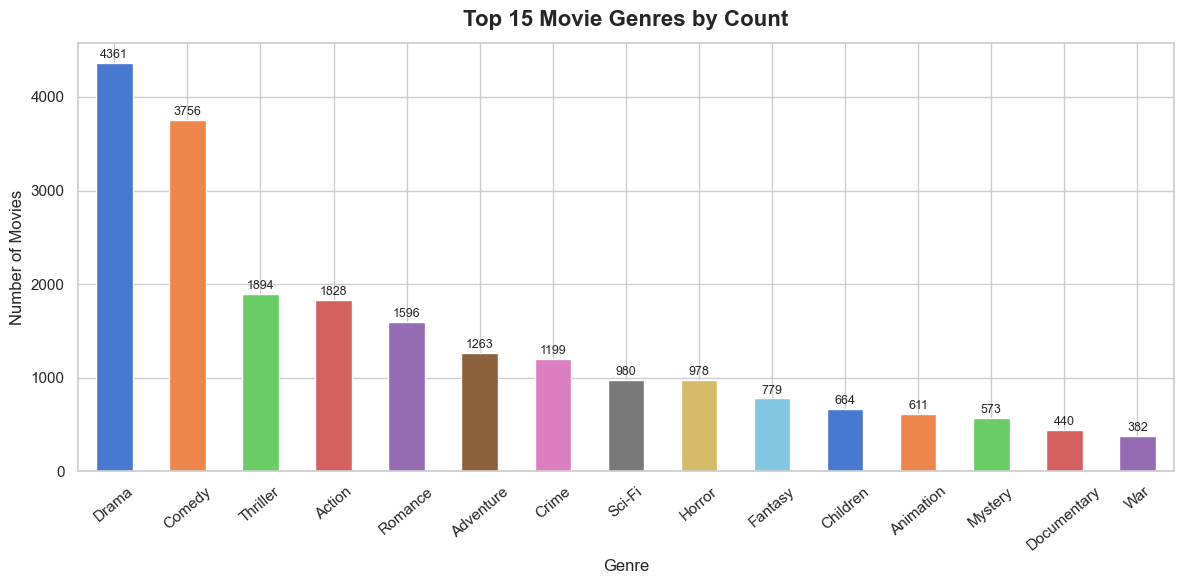

In [8]:
# Bar chart – Top 15 genres by number of movies
fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.head(15).plot(kind='bar', ax=ax, color=sns.color_palette('muted', 15), edgecolor='white')
ax.set_title('Top 15 Movie Genres by Count', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.tick_params(axis='x', rotation=40)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

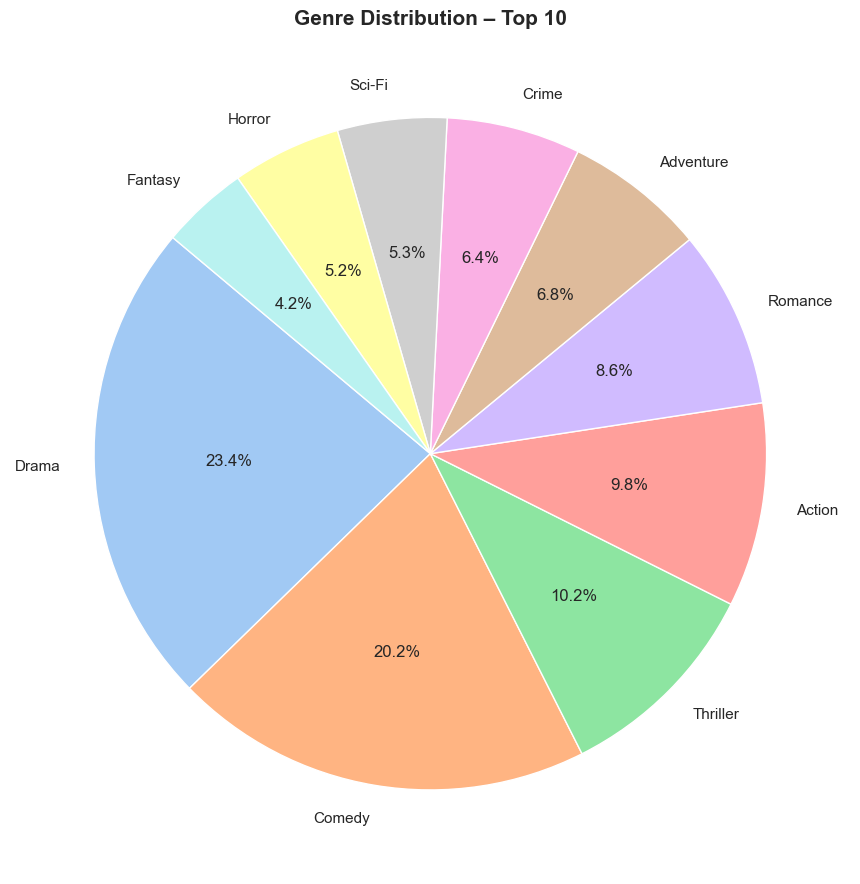

In [9]:
# Pie chart – Genre distribution (top 10)
top10 = genre_counts.head(10)
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    top10.values,
    labels=top10.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel', 10)
)
ax.set_title('Genre Distribution – Top 10', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Insight
> **Drama** and **Comedy** are by far the most common genres, together accounting for nearly half of all genre-label occurrences in the dataset. **Thriller**, **Action**, and **Romance** round out the top 5.

## 6. Movies Released Per Year

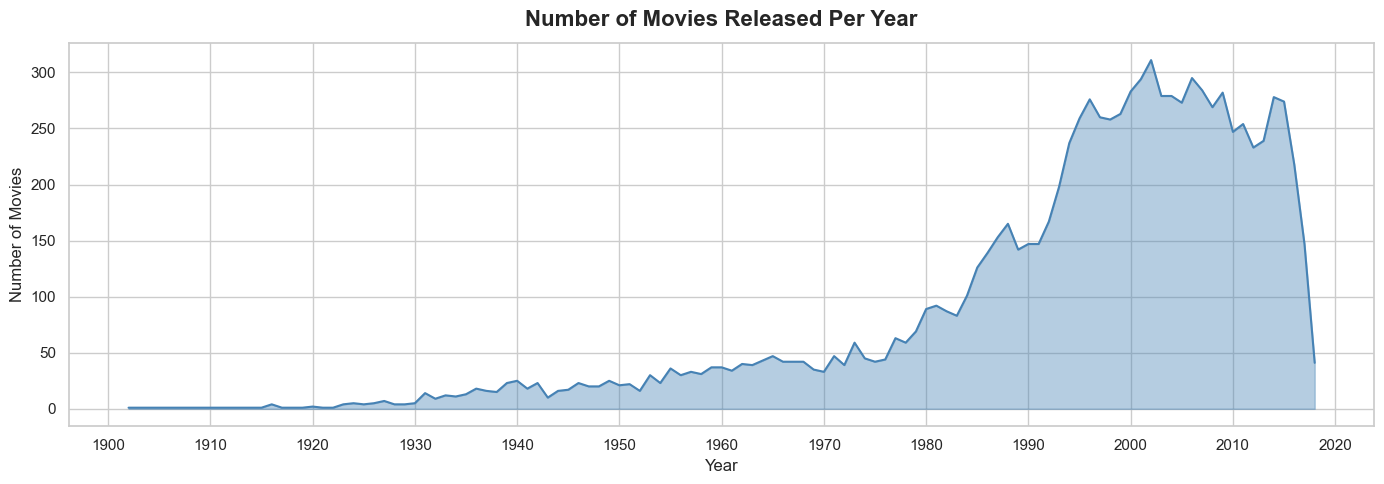

Peak year: 2002.0 with 311 movies


In [10]:
# Filter to valid years and common range
year_counts = df[df['Year'].between(1900, 2020)]['Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(year_counts.index, year_counts.values, alpha=0.4, color='steelblue')
ax.plot(year_counts.index, year_counts.values, color='steelblue', linewidth=1.5)
ax.set_title('Number of Movies Released Per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

print(f'Peak year: {year_counts.idxmax()} with {year_counts.max()} movies')

### 🔍 Insight
> Movie production grew steadily from the 1980s onwards, peaking around **2015–2016**. The sharp rise reflects both increased global film production and greater digital cataloguing.

## 7. Genre Trends Over Time
How have the top 5 genres evolved across decades?

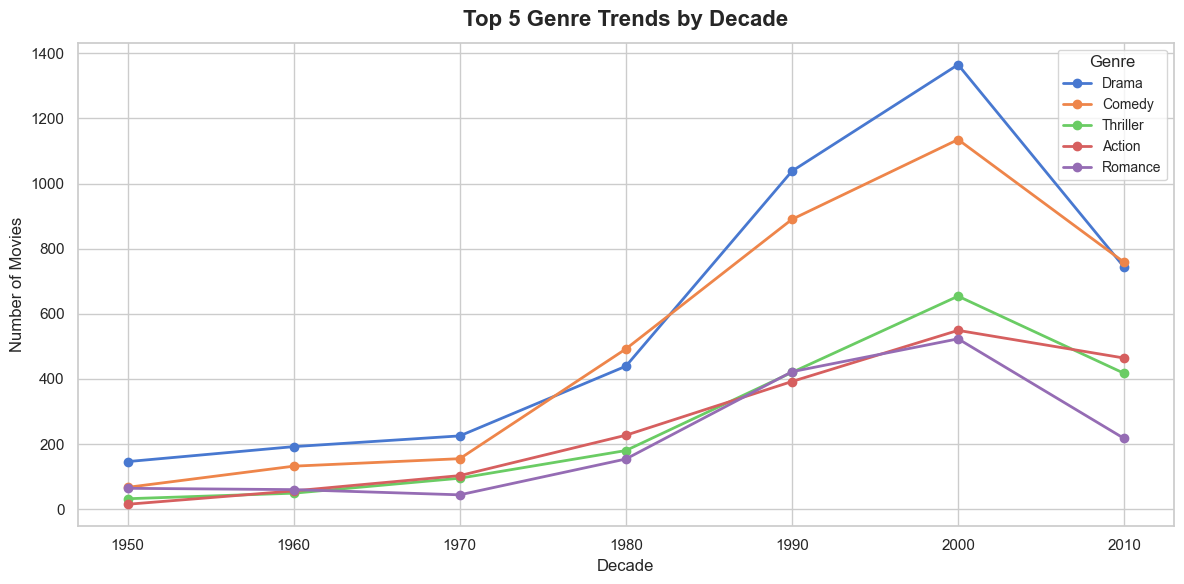

In [11]:
top5_genres = genre_counts.head(5).index.tolist()

# Decade column
genres_df['Decade'] = (genres_df['Year'] // 10 * 10).astype('Int64')
trend = (genres_df[genres_df['genre'].isin(top5_genres)]
         .groupby(['Decade', 'genre'])
         .size()
         .reset_index(name='count'))
trend = trend[trend['Decade'].between(1950, 2010)]

fig, ax = plt.subplots(figsize=(12, 6))
for genre in top5_genres:
    d = trend[trend['genre'] == genre]
    ax.plot(d['Decade'], d['count'], marker='o', label=genre, linewidth=2)

ax.set_title('Top 5 Genre Trends by Decade', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(title='Genre', fontsize=10)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

### 🔍 Insight
> **Drama** consistently dominates across all decades. **Comedy** surged in the 1990s–2000s. **Action** and **Thriller** grew significantly from the 1980s, reflecting audience appetite for blockbusters.

## 8. Number of Genres Per Movie

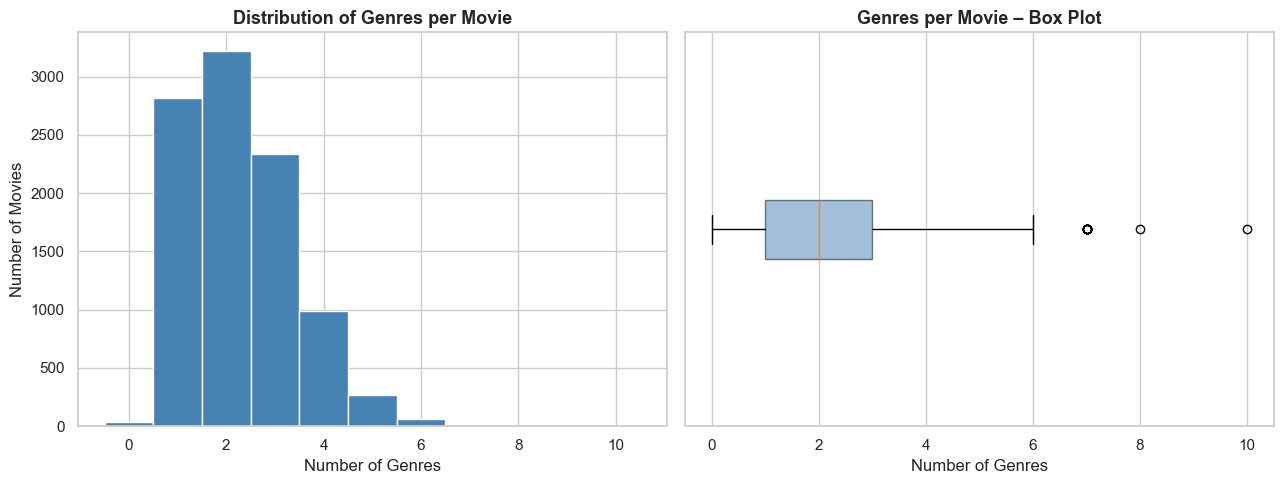

count    9742.000000
mean        2.263396
std         1.128720
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: genre_count, dtype: float64


In [12]:
df['genre_count'] = df['genres'].apply(lambda x: len([g for g in x.split('|') if g != '(no genres listed)']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['genre_count'], bins=range(0, df['genre_count'].max()+2),
             color='steelblue', edgecolor='white', align='left')
axes[0].set_title('Distribution of Genres per Movie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Genres')
axes[0].set_ylabel('Number of Movies')

# Box plot
axes[1].boxplot(df['genre_count'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Genres per Movie – Box Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Genres')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(df['genre_count'].describe())

### 🔍 Insight
> Most movies have **1 to 3 genres**. The median is around 2. Very few films have more than 5 genre labels.

## 9. Most Prolific Decades

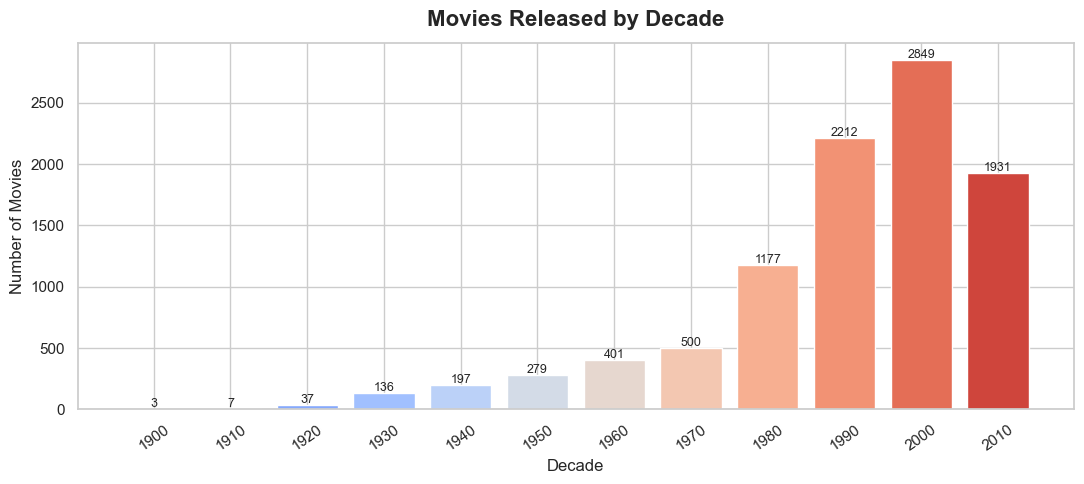

In [13]:
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')
decade_counts = df[df['Decade'].between(1900, 2010)]['Decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values,
              color=sns.color_palette('coolwarm', len(decade_counts)), edgecolor='white')
ax.set_title('Movies Released by Decade', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.tick_params(axis='x', rotation=35)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            int(bar.get_height()), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Summary of Key Findings

| Insight | Finding |
|---|---|
| Total movies | 9,742 |
| Year range | 1902 – 2018 |
| Most common genre | Drama (4,361 movies) |
| Second most common | Comedy (3,756 movies) |
| Average genres per movie | ~2 |
| Movies without year | 13 |
| Most productive decade | 2000s |

> **Conclusion:** The dataset is rich and mostly clean. Drama and Comedy dominate the genre landscape. Movie production accelerated significantly from the 1990s onward, peaking in the 2000s–2010s.

## 11. Save Cleaned Dataset

In [14]:
# Select and reorder columns for the clean output
df_clean = df[['movieId', 'Title', 'Year', 'genres']].copy()
df_clean.to_csv('movies_cleaned.csv', index=False)
print(f'Cleaned dataset saved as movies_cleaned.csv')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Cleaned dataset saved as movies_cleaned.csv
Shape: (9742, 4)


,movieId,Title,Year,genres
0,1,Toy Story,1995.0,Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji,1995.0,Adventure|Children|Fantasy
2,3,Grumpier Old Men,1995.0,Comedy|Romance
3,4,Waiting to Exhale,1995.0,Comedy|Drama|Romance
4,5,Father of the Bride Part II,1995.0,Comedy
